In [ ]:
# Imports
import pandas as pd
import numpy as np
import os
from functools import reduce
# plotting the distribution of the number of admissions per patient
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Importing DB...
BASE_DB = "mimic-iv-clinical-database-demo-2.2"
HOSP_PATH = os.path.join(BASE_DB, "hosp")
ICU_PATH = os.path.join(BASE_DB, "icu")

# Loading Tables...
patients = pd.read_csv(f'{HOSP_PATH}/patients.csv.gz')
admissions = pd.read_csv(f'{HOSP_PATH}/admissions.csv.gz')
lab_events = pd.read_csv(f'{HOSP_PATH}/labevents.csv.gz')
lab_items = pd.read_csv(f'{HOSP_PATH}/d_labitems.csv.gz')

chart_events = pd.read_csv(f'{ICU_PATH}/chartevents.csv.gz')
icu_stays = pd.read_csv(f'{ICU_PATH}/icustays.csv.gz')
d_items = pd.read_csv(f'{ICU_PATH}/d_items.csv.gz') 



# Step 1 : Data Exploring

In [ ]:
# exploring the different tables to then proceed to data cleaning and preprocessing
print("Patients:")
print(patients.head())
print("Admissions:")
print(admissions.head())
print("Lab Events:")
print(lab_events.head())
print("Lab Items:")
print(lab_items.head())
print("Chart Events:")
print(chart_events.head())
print("ICU Stays:") 
print(icu_stays.head())
print("D Items:")
print(d_items.head())


In [ ]:
# showing the number of rows and columns in each table
print("Patients shape:", patients.shape) # understanding the size of the data (based on how many patients we have)
print("Admissions shape:", admissions.shape) 
print("ICU Stays shape:", icu_stays.shape)
print("Chart Events shape:", chart_events.shape)
print("Chart Items shape:", d_items.shape)
print("Lab Events shape:", lab_events.shape)
print("Lab Items shape:", lab_items.shape)

In [ ]:
# exploring the data types and information about each table
print("------------------------------------------------------")
print("Patients info:")
print("------------------------------------------------------")
patients.info()

print("\n------------------------------------------------------")
print("Admissions info:")
print("------------------------------------------------------")
admissions.info()

print("\n------------------------------------------------------")
print("Chart Events info:")
print("------------------------------------------------------")
chart_events.info()

print("\n------------------------------------------------------")
print("Chart Items info:")
print("------------------------------------------------------")
d_items.info()

print("\n------------------------------------------------------")
print("Lab Events info:")
print("------------------------------------------------------")
lab_events.info()

print("\n------------------------------------------------------")
print("Lab Items info:")
print("------------------------------------------------------")
lab_items.info()


print("\n------------------------------------------------------")
print("ICU Stays info:")
print("------------------------------------------------------")
icu_stays.info()


In [ ]:
# finding duplicate values in each table
print("------------------------------------------------------")
print("Duplicates in Patients:")   
print("------------------------------------------------------")
print(patients.duplicated().sum())  # number of duplicate rows in each column

print("\n------------------------------------------------------")
print("Duplicates in Admissions:")
print("------------------------------------------------------")
print(admissions.duplicated().sum()) 

print("\n------------------------------------------------------")
print("Duplicates in ICU Stays:")
print("------------------------------------------------------")
print(icu_stays.duplicated().sum()) 

print("\n------------------------------------------------------")
print("Duplicates in Chart Events:")
print("------------------------------------------------------")
print(chart_events.duplicated().sum()) 

print("\n------------------------------------------------------")
print("Duplicates in Chart Items:")
print("------------------------------------------------------")
print(d_items.duplicated().sum()) 

print("\n------------------------------------------------------")
print("Duplicates in Lab Events:")
print("------------------------------------------------------")
print(lab_events.duplicated().sum()) 

print("\n------------------------------------------------------")
print("Duplicates in Lab Items:")
print("------------------------------------------------------")
print(lab_items.duplicated().sum()) 


In [ ]:
# extracting unique values from each table to understand the data better
# to understand how to transform the data and to find out if there are any categorical variables (string) that can be encoded
print("------------------------------------------------------")
print("Unique values in Patients:")
print("------------------------------------------------------")
# print unique values in each column of patients table where dtype is string
for col in patients.columns:
    if patients[col].dtype == 'str':
        print(f"*** {col}: {patients[col].unique()} \n")

print("\n------------------------------------------------------")
print("Unique values in Admissions:")
print("------------------------------------------------------")
for col in admissions.columns:
    if admissions[col].dtype == 'str':
        print(f"*** {col}: {admissions[col].unique()}\n")

print("\n------------------------------------------------------")
print("Unique values in ICU Stays:")
print("------------------------------------------------------")
for col in icu_stays.columns:
    if icu_stays[col].dtype == 'str':
        print(f"*** {col}: {icu_stays[col].unique()}\n")

print("\n------------------------------------------------------")
print("Unique values in Chart Events:")
print("------------------------------------------------------")
for col in chart_events.columns:
    if chart_events[col].dtype == 'str':
        print(f"*** {col}: {chart_events[col].unique()}\n")

print("\n------------------------------------------------------")
print("Unique values in Chart Items:")
print("------------------------------------------------------")
for col in d_items.columns:
    if d_items[col].dtype == 'str':
        print(f"*** {col}: {d_items[col].unique()}\n")

print("\n------------------------------------------------------")
print("Unique values in Lab Events:")
print("------------------------------------------------------")
for col in lab_events.columns:
    if lab_events[col].dtype == 'str':
        print(f"*** {col}: {lab_events[col].unique()}\n")
        
print("\n------------------------------------------------------")
print("Unique values in Lab Items:")
print("------------------------------------------------------")
for col in lab_items.columns:
    if lab_items[col].dtype == 'str':
        print(f"*** {col}: {lab_items[col].unique()}\n")


In [ ]:
# finding missing values in each table
# by defining the percentage of missing values in each column
print("------------------------------------------------------")
print("Missing values in Patients:")   
print("------------------------------------------------------")
print(patients.isnull().sum()/patients.shape[0]*100)  

print("\n------------------------------------------------------")
print("Missing values in Admissions:")
print("------------------------------------------------------")
print(admissions.isnull().sum()/admissions.shape[0]*100) 

print("\n------------------------------------------------------")
print("Missing values in ICU Stays:")
print("------------------------------------------------------")
print(icu_stays.isnull().sum()/icu_stays.shape[0]*100) 

print("\n------------------------------------------------------")
print("Missing values in Chart Events:")
print("------------------------------------------------------")
print(chart_events.isnull().sum()/chart_events.shape[0]*100) 

print("\n------------------------------------------------------")
print("Missing values in Chart Items:")
print("------------------------------------------------------")
print(d_items.isnull().sum()/d_items.shape[0]*100) 

print("\n------------------------------------------------------")
print("Missing values in Lab Events:")
print("------------------------------------------------------")
print(lab_events.isnull().sum()/lab_events.shape[0]*100) 

print("\n------------------------------------------------------")
print("Missing values in Lab Items:")
print("------------------------------------------------------")
print(lab_items.isnull().sum()/lab_items.shape[0]*100) 


------------------ Number of admissions per patient: ------------------
   subject_id  n_admissions
0    10000032             4
1    10001217             2
2    10001725             1
3    10002428             7
4    10002495             1

------------------ Number of ICU stays per patient: ------------------
   subject_id  n_icu_stays
0    10000032            1
1    10001217            2
2    10001725            1
3    10002428            4
4    10002495            1


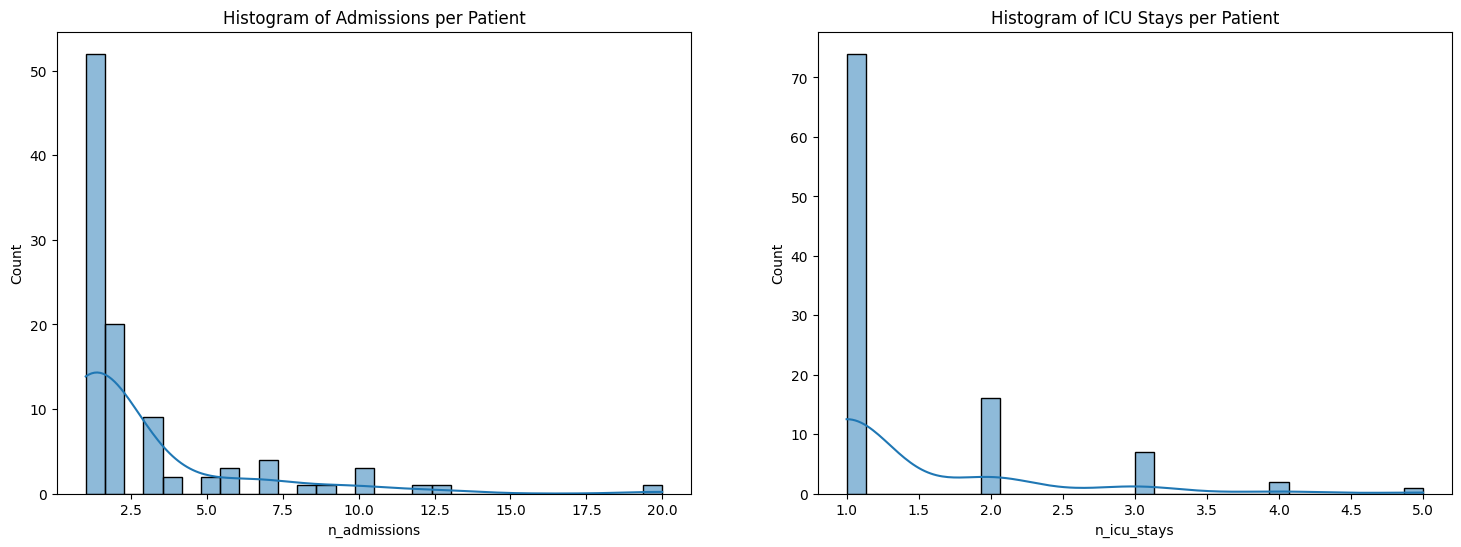

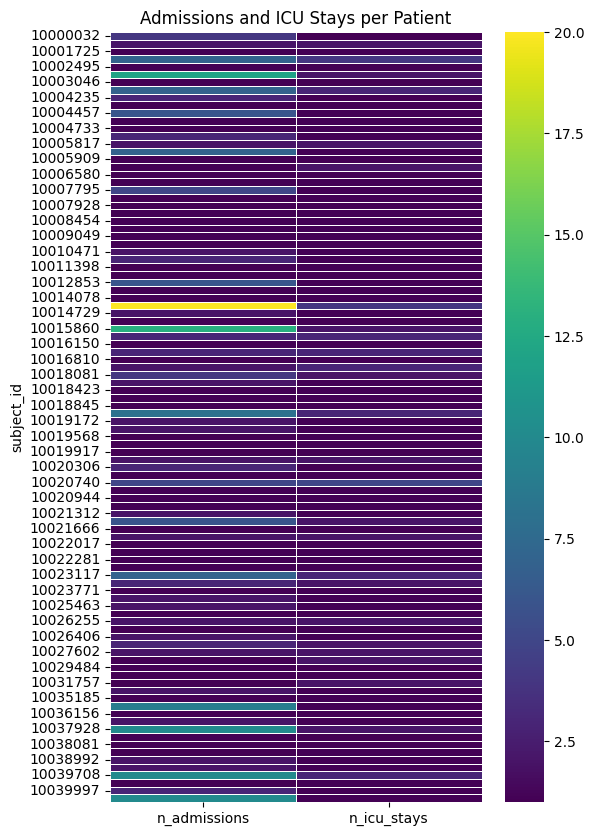

In [196]:
# counting the number of unique admissions and ICU stays for each patient
print("------------------ Number of admissions per patient: ------------------") 
admissions_per_patient = admissions.groupby("subject_id")["hadm_id"].nunique()
admissions_per_patient = admissions_per_patient.reset_index()
admissions_per_patient.columns = ["subject_id", "n_admissions"]
print(admissions_per_patient.head())

print("\n------------------ Number of ICU stays per patient: ------------------")
icu_stays_per_patient = icu_stays.groupby("subject_id")["stay_id"].nunique()
icu_stays_per_patient = icu_stays_per_patient.reset_index()
icu_stays_per_patient.columns = ["subject_id", "n_icu_stays"]
print(icu_stays_per_patient.head())

# Displaying the distribution of the number of admissions and ICU stays per patient 
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.histplot(admissions_per_patient['n_admissions'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Histogram of Admissions per Patient')

sns.histplot(icu_stays_per_patient['n_icu_stays'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Histogram of ICU Stays per Patient')
plt.show()

# creating a heatmap to show the number of admissions and ICU stays per patient
patient_summary = admissions_per_patient.merge(
    icu_stays_per_patient,
    on="subject_id",
    how="outer"
).fillna(0)
plt.figure(figsize=(6,10))

sns.heatmap(
    patient_summary.set_index("subject_id"),
    cmap="viridis",
    linewidths=0.5
)
plt.title("Admissions and ICU Stays per Patient")
plt.show()


In [ ]:
#Charevents table: understanding clinical variables
# each itemid represents the SAME clinical measurements in the ICU system (heart rate, blood pressure, respiratory rate, oxygen saturation)
# For example: the heart rate measurements could be mapped to multiple item_ids (for the same patient & icu stay)
df_vitals = chart_events[
    (chart_events["valueuom"].str.lower() == "bpm") &
    (chart_events["stay_id"] == 32604416)
]
df_unique_itemids = df_vitals.drop_duplicates(subset=["itemid"])
print(df_unique_itemids[["subject_id","stay_id","itemid","value" ,"valuenum", "valueuom"]].head())


# Step 2 : Data Cleaning

Handling missing values

In [ ]:
# ** The patients table: "dod" (date of death ) -> 69% missing, is not relevant since we will use the variable "hospital_expire_flag" to determine if the patient died during the hospital stay or not, so we can ignore the missing values in the "dod" column.
# ** The admssion table: "deathtime" -> 94% missing, not relevant since will use "hospital_expire_flag" 
# ** The ICU stays table: no missing data x)
# ** The chart events table: valuenom -> 26% missing | the columns "value" and "valuenum" are mutually exclusive, meaning they contain the same information in different formats "value" in string format and "valuenum" in numeric format.
#  For our analysis we will need the numeric format, so we will use the "valuenum" column 
# "valueom" column has 36% missing data, will be handled later if needed, --IGNORE--
chart_events = chart_events[chart_events["valuenum"].notna()]
chart_events.info()

In [ ]:
# ** the chart items table: "unitname" -> 72% missing, not relevant will use label to identify chart items found in chart events
# ** the lab events table: "valuenum" contains 9% missing
print("------------ labs events with missing values in valuenum ------------")
lab_events[lab_events['valuenum'].isnull()]
# we are going to drop the rows with missing data since it represents a small percentage of the data and we can't use filling methods to impute the missing values in the "valuenum" column since we don't have enough information to fill the missing data with a specific value (mean, median, mode) without introducing bias to the data.
lab_events = lab_events[lab_events['valuenum'].notna()]
lab_events.info()

In [ ]:
# the lab items table: the column "label" contains 0.18% missing values
print("------------ lab items with missing values in label ------------")
null_labs_label = lab_items[lab_items['label'].isna()]["itemid"].unique()
print(null_labs_label)
# drop rows with missing labels since we can't use them to identify the lab items
lab_items = lab_items[~lab_items['label'].isin(null_labs_label)]
lab_events = lab_events[lab_events['itemid'].isin(lab_items['itemid'])]  # keep only lab events with valid itemids in lab items table
print(" \n------------ lab items info after dropping rows with missing labels ------------")
lab_items.info()

# Step 3 : Variables Extraction | Feature Definition

In [ ]:
#convert to datetime
icu_stays['intime'] = pd.to_datetime(icu_stays['intime'])
icu_stays['outtime'] = pd.to_datetime(icu_stays['outtime'])

# Select first ICU stay per patient
icu_stays = icu_stays.sort_values(by="intime")
icu_stay_first = icu_stays.groupby("subject_id").first()

# add the patients' demographics based on the chosen icu stay
df = icu_stay_first.merge(patients, on="subject_id")

# add relevant hospital admission
df = df.merge(admissions, on=["subject_id", "hadm_id"])

# Keep relevant columns
df = df[[
     "subject_id","hadm_id", 
     "stay_id", "first_careunit",
     "anchor_age", "gender",
     "admission_type", "hospital_expire_flag",
     "intime", "outtime"
]]
df.head()



In [ ]:
####### Define chartevents for 24H window (var:24H_endtime)
# 1- Calculate the 24H_endtime based on each icu_stay intime
# 2- Extract the chartevents done in those 24H
df["24H_endtime"] = df["intime"] + pd.Timedelta(hours=24)
chart_events["charttime"] = pd.to_datetime(chart_events["charttime"])
chart_events = chart_events.merge(
    df[["stay_id", "intime", "24H_endtime"]],
    on="stay_id"
)

chart_events_24H = chart_events[
    (chart_events["charttime"] >= chart_events["intime"]) &
    (chart_events["charttime"] <= chart_events["24H_endtime"])
]

chart_events_24H.head()

In [ ]:
#Different and most important vital signs extracted in the 24H window
# count of each unit of measurement ==> vital sign
# chart_events_24H["valueuom"].value_counts().head(15)
# items where unitname are the ones in the chart_events_24H andlabel and itemid
temp_items = d_items.loc[
    d_items["unitname"].str.lower().isin(
        chart_events_24H["valueuom"].str.lower().dropna().unique()
    ),
    ["itemid", "label", "unitname","category"]
]
#add count by itemid by ignoring NaN values
chart_items = chart_events_24H[chart_events_24H["valueuom"].notna()]["itemid"].value_counts().reset_index()
chart_items.columns = ["itemid", "count"]
#merge with temp_items to get the label and unitname for each itemid
chart_items = chart_items.merge(temp_items, on="itemid", how="left")

chart_items.sort_values(by="count", ascending=False).head(30).groupby("category").head()


In [ ]:
# 3- Map each vital sign variable (heart rate, blood pressure, respiratory rate, oxygen saturation) to the corresponding itemids
def vars_mapping(tb_items,column,keyword):
    return tb_items[tb_items[column].str.contains(keyword, case=False)]["itemid"].tolist()

vital_sign_ids = {
    "HR": vars_mapping(d_items, "label", "heart rate"), # Heart Rate
    "BP": vars_mapping(d_items, "label", "blood pressure"), # Blood Pressure
    "RR": vars_mapping(d_items, "label", "respiratory rate"), # Respiratory Rate
    "SpO2": vars_mapping(d_items, "label", "spo2 | oxygen saturation | o2 saturation"), # O2 Saturation
    # "TemperatureF": vars_mapping(d_items, "label", "Temperature Fahrenheit") # Temperature Farenheit  
}

print(vital_sign_ids)

In [ ]:
# 4- Add the vital signs values in the 24H window to the main df based on the itemids mapping

# for vital_sign, itemids in vital_sign_ids.items():
#     df_vital = chart_events_24H[chart_events_24H["itemid"].isin(itemids)]
#     df_vital = df_vital[["stay_id", "valuenum"]].groupby("stay_id").median()
#     df_vital.rename(columns={"valuenum": vital_sign}, inplace=True)
#     df = df.merge(df_vital, on="stay_id", how="left")   

##### ICU data is all about extremes and critical events (max, min)  
# the median will help up determine the typical state
vitals_list = []
for vital, ids in vital_sign_ids.items():
    temp = chart_events_24H[chart_events_24H["itemid"].isin(ids)]
    
    agg = temp.groupby("stay_id")["valuenum"].agg(
        ["median", "min", "max"]
    ).reset_index()
    
    agg.columns = ["stay_id",
                   f"{vital}_median",
                   f"{vital}_min",
                   f"{vital}_max"]
    
    vitals_list.append(agg)

# Merge all vitals in a DataFrame
vitals_df = reduce(lambda left, right: pd.merge(left, right, on="stay_id", how="outer"), vitals_list)

vitals_df.head()


In [ ]:
df = df.merge(vitals_df, on="stay_id", how="left")
df.head()

to capture to icu patients' situation we are extracting only the labs done in the first 24H of admission. these labs results will help us determine the factors contributing to each patient's acquity level

In [ ]:
######### Define labevents 
# 1- Keep only the lab_events with hadm_id in our main df
lab_events = lab_events[
    lab_events["hadm_id"].isin(df["hadm_id"])
]
# Extract the labevents done in those 24H 
lab_events["charttime"] = pd.to_datetime(lab_events["charttime"])


lab_events = lab_events.merge(
    df[["hadm_id", "intime", "24H_endtime"]],
    on="hadm_id"
)

lab_events_24H = lab_events[
    (lab_events["charttime"] >= lab_events["intime"]) &
    (lab_events["charttime"] <= lab_events["24H_endtime"])
]

lab_events_24H.head()

Most important criteria for labs features/variables selection: \
1- count the number of lab items (by itemsid) to extract labs that are commonly ordered in the ICU \
2- where the valuenum is not null (to avoid counting the lab tests that were ordered but not done)\
3- labs that reflect acquity

In [ ]:

labs = lab_events_24H[lab_events_24H["valuenum"].notnull()]

items = lab_items[["itemid", "label","category"]]
labs = labs.merge(items, on="itemid", how="left")
labs_count = labs["itemid"].value_counts().reset_index()
labs_count.columns = ["itemid", "count"]
labs_count = labs_count.merge(items, on="itemid", how="left")
labs_count.head(30).sort_values(by="count", ascending=False)

- labs that are commonly ordered in the ICU and reflect acuity: \
1- *Blood Gas Analysis (ABG):* pH, Lactate (important for Organ function) \
2- *Electrolytes:* Sodium, Potassium, Chloride, Calcium, Magnesium -> useful for phenotypes \
3-* Organ/Renal Function:* Creatinine, Blood Urea Nitrogen (BUN) \
4- *Hematology:* Hemoglobin, WBC, Platelet Count \
5- *Metabolic:* Glucose, Anion Gap



In [ ]:
# 3- Map each lab variable to the corresponding itemids
lab_ids = {
    "pH" : vars_mapping(lab_items, "label", "ph"),
    "Lactate" : vars_mapping(lab_items, "label", "lactate"),
    "Sodium" : vars_mapping(lab_items, "label", "sodium"),
    "Potassium" : vars_mapping(lab_items, "label", "potassium"),
    "Chloride" : vars_mapping(lab_items, "label", "chloride"),
    "Calcium" : vars_mapping(lab_items, "label", "calcium"),
    "Magnesium" : vars_mapping(lab_items, "label", "magnesium"),
    "Hemoglobin" : vars_mapping(lab_items, "label", "hemoglobin"),
    "Platelets" : vars_mapping(lab_items, "label", "platelets"),
    "WBC" : vars_mapping(lab_items, "label", "white blood cell"),
    "Glucose" : vars_mapping(lab_items, "label", "glucose"),
    "BUN" : vars_mapping(lab_items, "label", "blood urea nitrogen"),
    "Creatinine" : vars_mapping(lab_items, "label", "creatinine"),
    "AnionGap" : vars_mapping(lab_items, "label", "anion gap")
}
print(lab_ids)

    

In [ ]:
# 4- Add the lab to the main df
labs_list = []
for lab, ids in lab_ids.items():
    temp = lab_events_24H[lab_events_24H["itemid"].isin(ids)]
    lab_agg = temp.groupby("hadm_id")["valuenum"].agg(["median", "max"])
    lab_agg.columns = [f"{lab}_median", f"{lab}_max"]
    labs_list.append(lab_agg.reset_index())

    # Merge all labs in a DataFrame
labs_df = reduce(lambda l, r: pd.merge(l, r, on="hadm_id", how="outer"), labs_list)
labs_df.head(30)

In [ ]:
df = df.merge(labs_df, on="hadm_id", how="left")
df.head()

# Step 4: Data Standarization